# «Клевер»: вопрос написал редактор или игрок?

**Задача.** В «Клевере» игроки отвечают на 12–15 вопросов с тремя вариантами ответа. Часть вопросов пишут профессиональные редакторы, часть присылают сами пользователи. Нужна модель, которая по тексту вопроса оценит вероятность, что его автор — редактор.

**Данные.** 41 087 вопросов (`data.csv`). Для 30 000 из них известен автор (`train.csv`: 1 — редактор, 0 — пользователь). Для 11 087 вопросов из `test.csv` нужно выдать вероятность.

**Цель проекта** — получить файл `ID, вероятность` для тестовой выборки и модель, которую можно встроить в модерацию: например, чтобы пользовательские вопросы редакторского качества поднимались в очереди выше.

**Задачи:**
1. Разобраться в данных, в том числе в формате файлов.
2. Найти признаки, по которым редакторский вопрос отличается от пользовательского.
3. Собрать модель и честно оценить её качество.
4. Выбрать порог на случай, если нужна жёсткая метка.
5. Сформировать файл с ответом.

**Метрика.** В задании её не назвали. Ответ — вероятность, классы несбалансированы (редакторских около 10%), поэтому основная метрика — **ROC-AUC**. Дополнительно смотрю **Average Precision** (площадь под PR-кривой): она чувствительнее к качеству на редком классе.

**Каким должен быть результат:** воспроизводимый ноутбук, честная оценка на кросс-валидации, понятные признаки и файл ответа в формате `baseline_solution.csv`.

In [1]:
import re, warnings, time
import numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, f1_score, confusion_matrix)
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .3, 'font.size': 10})
USER, EDITOR = '#9aa5b1', '#d9480f'   # цвета классов на всех графиках
SEED = 42

## 1. Загрузка данных

Первая ловушка. `data.csv` разделён точкой с запятой, но в некоторых вопросах «;» стоит прямо в тексте. Обычный `pd.read_csv(sep=';')` на таких строках спотыкается и молча их выбрасывает. Поэтому делю каждую строку по **первой** точке с запятой: слева ID, справа весь вопрос.

In [2]:
rows = []
with open('data.csv', encoding='utf-8') as f:
    next(f)
    for line in f:
        i, q = line.rstrip('\r\n').split(';', 1)
        rows.append((int(i), q))
d = pd.DataFrame(rows, columns=['ID', 'Question'])
labels = pd.read_csv('train.csv', sep=';')
test_ids = pd.read_csv('test.csv')

broken = d[d.Question.str.contains(';')]
print(f'Всего вопросов: {len(d)}, ID уникальны: {d.ID.is_unique}')
print(f'Строк с «;» внутри текста (read_csv бы их потерял): {len(broken)}')
print(f'Размечено: {len(labels)}, в тесте: {len(test_ids)}, у всех тестовых ID есть текст: {test_ids.ID.isin(d.ID).all()}')
broken.head(3)

Всего вопросов: 41087, ID уникальны: True
Строк с «;» внутри текста (read_csv бы их потерял): 10
Размечено: 30000, в тесте: 11087, у всех тестовых ID есть текст: True


,ID,Question
1228,1229,"""Какой остров разделён государственной границей? (Прим.: российская Новая Земля - архипелаг, а не остров; остров Нов..."
3209,3210,"""<!— Put this script tag to the <head> of your page —> <script type=""""text/javascript"""" src=""""https://vk.com/js/api..."
6075,6076,"""Кто сказал: «...довольно людей кормили сластями; у них от этого испортился желудок...»"""


In [3]:
tr = d.merge(labels, on='ID')
te = test_ids.merge(d, on='ID', how='left')
y = tr.Answer.values
print(tr.Answer.value_counts().rename({0: 'пользователь (0)', 1: 'редактор (1)'}))
print(f'Доля редакторских вопросов: {y.mean():.1%}')

Answer
пользователь (0)    26884
редактор (1)         3116
Name: count, dtype: int64
Доля редакторских вопросов: 10.4%


## 2. Исследование данных

### 2.1. Как выглядят вопросы

In [4]:
print('РЕДАКТОРЫ:'); print(tr[tr.Answer == 1].Question.sample(8, random_state=1).to_string(index=False))
print('\nПОЛЬЗОВАТЕЛИ:'); print(tr[tr.Answer == 0].Question.sample(8, random_state=1).to_string(index=False))

РЕДАКТОРЫ:
                       В каком фильме НЕ снимался Джим Керри?
                 Какое из этих животных НЕ является всеядным?
Какая планета в солнечной системе движется быстрее остальных?
                Какова численность группы Гавайских островов?
             По какому признаку гиен относят к кошкообразным?
     Как раньше называлась столица Республики Коми Сыктывкар?
             Кто выиграл Чемпионат мира по футболу 2010 года?
                    Как звали медведя в мультфильме «Маугли»?

ПОЛЬЗОВАТЕЛИ:
                                                   Бывает ли чёрное мороженое?
Кем были люди,которые решили выступить во время начала царствования Николая I?
                                                кто самый популярный на ютубе?
                               Как называется известная песня Игоря Николаева?
                                             Сколько полушек было в 1 алтыне ?
                       В каком году родилась французский модельер Коко Шанель?
   К

Уже на глаз видна разница. У редакторов вопрос всегда заканчивается знаком «?», названия стоят в «ёлочках», отрицание выделено капсом («НЕ»). У пользователей встречаются прямые кавычки `""`, точка вместо вопросительного знака, «Клубника это...», капс на весь вопрос, опечатки. Проверю это на цифрах.

### 2.2. Длина вопроса

          count  mean   std   min   25%   50%   75%     max
Answer                                                     
0       26884.0  50.7  29.1   1.0  34.0  46.0  61.0  1054.0
1        3116.0  52.4  17.7  16.0  40.0  50.0  63.0   166.0


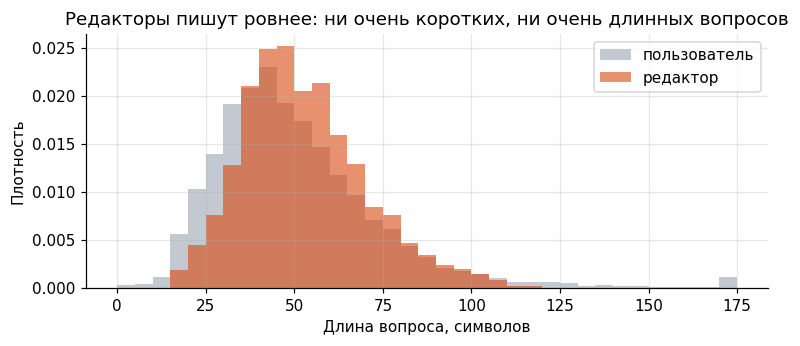

In [5]:
tr['len'] = tr.Question.str.len()
print(tr.groupby('Answer')['len'].describe().round(1))
fig, ax = plt.subplots(figsize=(8, 3))
bins = np.arange(0, 180, 5)
for lab, c, name in [(0, USER, 'пользователь'), (1, EDITOR, 'редактор')]:
    ax.hist(tr[tr.Answer == lab]['len'].clip(upper=175), bins=bins, density=True, alpha=.6, color=c, label=name)
ax.set(xlabel='Длина вопроса, символов', ylabel='Плотность', title='Редакторы пишут ровнее: ни очень коротких, ни очень длинных вопросов')
ax.legend(); plt.show()

Средняя длина почти одинаковая, а разброс разный. У пользователей встречаются вопросы из одного символа и простыни на тысячу знаков. Редакторские укладываются в 16–166 символов.

### 2.3. Оформление — главный стилистический сигнал

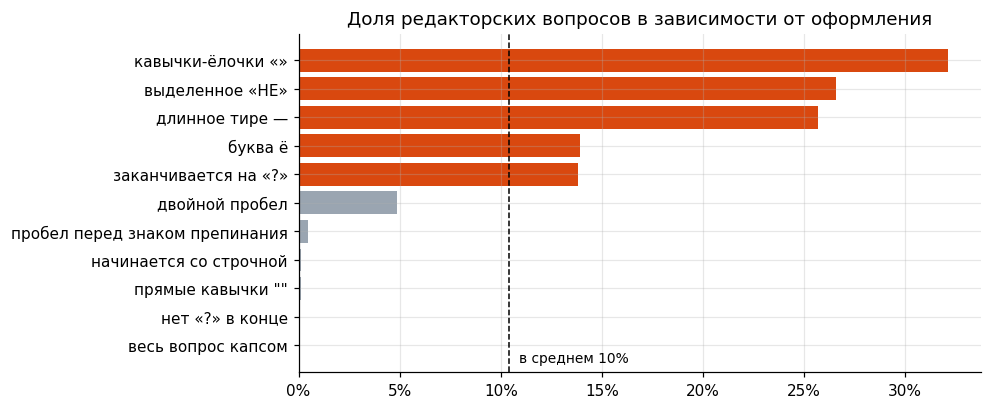

,встречается,доля редакторов среди таких,вопросов
признак,,,
заканчивается на «?»,75.0%,13.8%,22510
нет «?» в конце,25.0%,0.0%,7490
кавычки-ёлочки «»,5.5%,32.1%,1656
"прямые кавычки """"",3.0%,0.1%,897
выделенное «НЕ»,2.2%,26.6%,670
длинное тире —,0.2%,25.7%,74
буква ё,6.2%,13.9%,1871
двойной пробел,2.7%,4.9%,804
пробел перед знаком препинания,4.9%,0.5%,1479


In [6]:
checks = {
    'заканчивается на «?»':        lambda s: s.strip().endswith('?'),
    'нет «?» в конце':             lambda s: not s.strip().endswith('?'),
    'кавычки-ёлочки «»':           lambda s: '«' in s,
    'прямые кавычки ""':           lambda s: '"' in s,
    'выделенное «НЕ»':             lambda s: bool(re.search(r'\bНЕ\b', s)),
    'длинное тире —':              lambda s: '—' in s,
    'буква ё':                     lambda s: 'ё' in s.lower(),
    'двойной пробел':              lambda s: '  ' in s,
    'пробел перед знаком препинания': lambda s: bool(re.search(r'\s[?,.!:]', s)),
    'начинается со строчной':      lambda s: not s.strip()[:1].isupper(),
    'весь вопрос капсом':          lambda s: s.strip().isupper(),
}
rep = []
for name, f in checks.items():
    m = tr.Question.map(f)
    rep.append((name, m.mean(), tr.Answer[m].mean() if m.any() else np.nan, m.sum()))
rep = pd.DataFrame(rep, columns=['признак', 'встречается', 'доля редакторов среди таких', 'вопросов']).set_index('признак')
fig, ax = plt.subplots(figsize=(8, 4))
r = rep.sort_values('доля редакторов среди таких')
ax.barh(r.index, r['доля редакторов среди таких'], color=[EDITOR if v > y.mean() else USER for v in r['доля редакторов среди таких']])
ax.axvline(y.mean(), color='k', ls='--', lw=1); ax.text(y.mean() + .005, -0.6, f'в среднем {y.mean():.0%}', fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set(title='Доля редакторских вопросов в зависимости от оформления', xlabel='')
plt.show()
rep.style.format({'встречается': '{:.1%}', 'доля редакторов среди таких': '{:.1%}'})

Картина однозначная. **Среди вопросов без «?» в конце нет ни одного редакторского.** Среди вопросов с прямыми кавычками почти нет. Строчная буква в начале и капс тоже выдают пользователя. «Ёлочки», «НЕ» капсом и длинное тире, наоборот, в 2,5–3 раза повышают шанс, что вопрос редакторский.

Отсюда вывод: оформление важнее содержания. Правильно оформить вопрос пользователь может, а вот неряшливо оформленный вопрос от редактора почти не встречается.

### 2.4. Дубли — самая сильная находка

Вопросов, у которых есть точный дубль (после нормализации): 22.3%


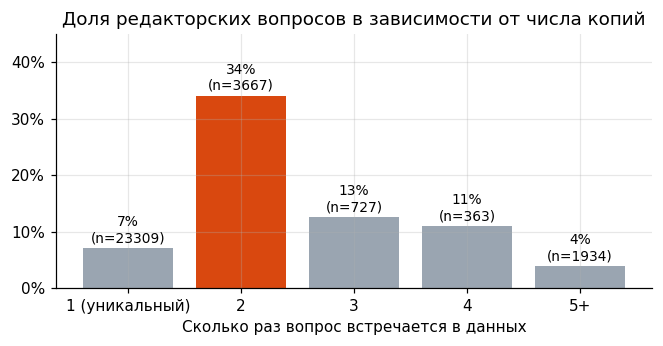

In [7]:
norm = lambda s: re.sub(r'\W+', ' ', s.lower().replace('ё', 'е')).strip()
d['norm'] = d.Question.map(norm)
d['gsize'] = d.groupby('norm').ID.transform('size')
tr = tr.merge(d[['ID', 'norm', 'gsize']], on='ID')
print(f'Вопросов, у которых есть точный дубль (после нормализации): {(d.gsize > 1).mean():.1%}')

g = tr.groupby(tr.gsize.clip(upper=5)).Answer.agg(['mean', 'size'])
g.index = ['1 (уникальный)', '2', '3', '4', '5+']
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(g.index, g['mean'], color=[USER, EDITOR, USER, USER, USER])
for i, (m, n) in enumerate(zip(g['mean'], g['size'])): ax.text(i, m + .01, f'{m:.0%}\n(n={n})', ha='center', fontsize=9)
ax.set(title='Доля редакторских вопросов в зависимости от числа копий', xlabel='Сколько раз вопрос встречается в данных', ylim=(0, .45))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}')); plt.show()

In [8]:
# полностью размеченные группы дублей: сколько в них редакторских вопросов
full = tr[tr.groupby('norm').ID.transform('size') == tr.gsize]
s = full.groupby('norm').Answer.agg(['sum', 'size'])
ct = pd.crosstab(s['size'].clip(upper=4).rename('размер группы'), s['sum'].clip(upper=2).rename('редакторских в группе'))
print(ct)
print('\nПример пары:')
ex = s[(s['size'] == 2) & (s['sum'] == 1)].index[:4]
tr[tr.norm.isin(ex)].sort_values('norm')[['ID', 'Question', 'Answer']]

редакторских в группе      0     1  2
размер группы                        
1                      21652  1657  0
2                        428   921  4
3                         77    37  5
4                         42    12  5

Пример пары:


,ID,Question,Answer
8113,8114,Блюдом какой кухни являются перепечи?,0
22370,22371,Блюдом какой кухни являются перепечи?,1
20243,20244,В какой из этих игр обходятся без клюшек?,1
27988,27989,В какой из этих игр обходятся без клюшек?,0
28786,28787,В какой из этих стран есть император?,1
29598,29599,В какой из этих стран есть император?,0
21131,21132,В какой из этих стран мира самый большой запас пресной воды?,1
23702,23703,В какой из этих стран мира самый большой запас пресной воды?,0


Вот ради чего стоило копать. Игроки часто присылают вопросы, которые уже видели в игре, — иногда слово в слово. Среди полностью размеченных пар в **921 паре из 1 353 ровно один вопрос редакторский, а второй — его пользовательская копия.** Пар из двух редакторских всего четыре.

Для модели это значит две вещи:
* наличие близкого двойника само по себе повышает вероятность, что перед нами редакторский оригинал или копия с него;
* если метка двойника уже известна, она почти решает задачу: двойник-редактор означает, что наш вопрос — копия, и наоборот.

Двойники бывают неточными: другой регистр, опечатка, лишнее слово. Поэтому ищу не только точные совпадения, но и ближайших соседей по символьному TF-IDF.

### 2.5. Проверка на утечку через ID

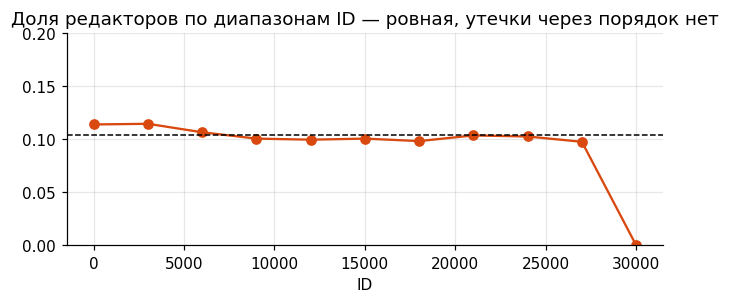

In [9]:
b = tr.groupby(tr.ID // 3000).Answer.mean()
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(b.index * 3000, b.values, marker='o', color=EDITOR); ax.axhline(y.mean(), color='k', ls='--', lw=1)
ax.set(title='Доля редакторов по диапазонам ID — ровная, утечки через порядок нет', xlabel='ID', ylim=(0, .2))
plt.show()

## 3. Признаки

Три группы:
1. **Оформление и стиль** — 30 ручных признаков: знаки препинания, кавычки, регистр, пробелы, длина, цифры, латиница.
2. **Текст** — TF-IDF по символьным 1–5-граммам с учётом регистра (ловит и стиль, и лексику) и по словам и биграммам.
3. **Соседи и дубли** — размер группы точных дублей, сходство с тремя ближайшими вопросами, известные метки соседей и то, насколько вопрос «редакторее» своих двойников.

In [10]:
cnt_norm = d.norm.value_counts(); cnt_raw = d.Question.value_counts()
def hand(s):
    st = s.strip(); w = st.split()
    return dict(
        len=len(s), nwords=len(w), avg_word=np.mean([len(x) for x in w]) if w else 0,
        ends_q=st.endswith('?'), ends_dot=st.endswith('.'), ends_ellipsis=st.endswith('...') or st.endswith('…'),
        n_q=s.count('?'), guillemets=s.count('«'), straight_quotes=s.count('"'), yo='ё' in s.lower(),
        caps_NE=bool(re.search(r'\bНЕ\b', s)), caps_words=sum(1 for x in w if len(x) > 2 and x.isupper()),
        all_upper=st.isupper(), starts_upper=st[:1].isupper(), em_dash='—' in s, spaced_hyphen=' - ' in s,
        double_space='  ' in s, outer_spaces=s != st, space_before_punct=bool(re.search(r'\s[?,.!:]', s)),
        no_space_after_comma=bool(re.search(r',\S', s)), digits=sum(c.isdigit() for c in s),
        latin=sum(c.isascii() and c.isalpha() for c in s), exclamation='!' in s, parentheses='(' in s,
        commas=s.count(','), upper_ratio=sum(c.isupper() for c in s) / max(1, len(s)),
        odd_chars=sum(1 for c in s if not (c.isalnum() or c in ' ?,.!:;«»"()-—–\'')),
        dup_norm=cnt_norm[norm(s)], dup_raw=cnt_raw[s], ellipsis_inside='...' in st[:-3])
H = pd.DataFrame([hand(s) for s in d.Question]).astype(float)
HAND_NAMES = list(H.columns); Hm = H.values
N = len(d); pos = {i: k for k, i in enumerate(d.ID)}
itr = np.array([pos[i] for i in tr.ID]); ite = np.array([pos[i] for i in te.ID])
print('Ручных признаков:', Hm.shape[1])

Ручных признаков: 30


In [11]:
t0 = time.time()
allq = d.Question.values
Xc = TfidfVectorizer(analyzer='char', ngram_range=(1, 5), lowercase=False, min_df=3, sublinear_tf=True, max_features=300_000).fit_transform(allq)
Xw = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, sublinear_tf=True, token_pattern=r'(?u)\b\w+\b').fit_transform(allq)
X = sp.hstack([Xc, Xw]).tocsr()
print(f'TF-IDF: {X.shape[1]:,} признаков, {time.time()-t0:.0f} с')

# ближайшие соседи: косинус по символьным 3–4-граммам нормализованного текста
V = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), min_df=2, sublinear_tf=True).fit_transform(d.norm.values).astype(np.float32)
K = 5; nn_idx = np.zeros((N, K), int); nn_sim = np.zeros((N, K), np.float32)
for s in range(0, N, 2000):
    S = (V[s:s+2000] @ V.T).toarray()
    S[np.arange(S.shape[0]), np.arange(s, s + S.shape[0])] = -1   # сам с собой не сосед
    top = np.argpartition(-S, K, axis=1)[:, :K]; ts = np.take_along_axis(S, top, 1); o = np.argsort(-ts, 1)
    nn_idx[s:s+2000] = np.take_along_axis(top, o, 1); nn_sim[s:s+2000] = np.take_along_axis(ts, o, 1)
print(f'Соседи найдены, {time.time()-t0:.0f} с. Медиана сходства с ближайшим: {np.median(nn_sim[:,0]):.2f}, '
      f'доля вопросов с соседом ≥0,8: {(nn_sim[:,0] >= .8).mean():.1%}')

gid = d.groupby('norm').ngroup().values
members = pd.Series(np.arange(N)).groupby(gid).apply(list).to_dict()
gsize = d.gsize.values

TF-IDF: 203,423 признаков, 6 с


Соседи найдены, 58 с. Медиана сходства с ближайшим: 0.66, доля вопросов с соседом ≥0,8: 37.1%


## 4. Схема валидации

Здесь легко обмануть себя. Признак «метка двойника» строится из тех же меток, которые модель предсказывает. Если на обучении модель видит метку соседа из той же выборки, а на тесте такой роскоши нет, оценка получится завышенной.

Поэтому валидация вложенная:
* **внешние 5 фолдов** дают честную оценку, их метки полностью скрыты;
* внутри обучающей части признаки первого уровня (TF-IDF-регрессия, стилистический бустинг) считаются out-of-fold;
* групповые признаки для обучающих строк тоже считаются out-of-fold: при их расчёте метки своего внутреннего фолда скрыты.

На тесте скрыто около 27% всех вопросов. На валидации скрыт тест плюс валидационный фолд. Условия близки к боевым, а если и отличаются, то в пессимистичную сторону.

In [12]:
P1 = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=30, feature_fraction=0.8,
          bagging_fraction=0.8, bagging_freq=1, lambda_l2=1, verbose=-1)
# параметры второго уровня подобраны перебором (см. раздел 6)
P2 = dict(P1, learning_rate=0.01, num_leaves=7, feature_fraction=0.5); ROUNDS2 = 4000
SEEDS = [42, 7, 2024]

def stage1(train_idx, ytr):
    # Уровень 1: LR на TF-IDF и LGBM на ручных признаках + скор LR.
    # Для train_idx — OOF-прогноз, для остальных строк — среднее по фолдам.
    s_lr, s1 = np.zeros(N), np.zeros(N); other = np.setdiff1d(np.arange(N), train_idx)
    kf = StratifiedKFold(5, shuffle=True, random_state=1)
    for a, b in kf.split(train_idx, ytr):
        m = LogisticRegression(C=4, max_iter=3000, class_weight='balanced').fit(X[train_idx[a]], ytr[a])
        s_lr[train_idx[b]] = m.predict_proba(X[train_idx[b]])[:, 1]; s_lr[other] += m.predict_proba(X[other])[:, 1] / 5
    F = np.column_stack([Hm, s_lr])
    for a, b in kf.split(train_idx, ytr):
        m = lgb.train(P1, lgb.Dataset(F[train_idx[a]], ytr[a]), 600)
        s1[train_idx[b]] = m.predict(F[train_idx[b]]); s1[other] += m.predict(F[other]) / 5
    return s_lr, s1

GROUP_NAMES = ['grp_size', 'grp_known', 'grp_known_editor', 'grp_known_user', 'nn_close', 'nn_known',
               'nn_known_editor', 'nn_sim_top1', 'nn_sim_top3', 's1_minus_best_twin', 's1_rank_among_twins', 'n_twins']
def group_feats(known, s1, rows):
    # known — метки, которые разрешено видеть (NaN там, где скрыто)
    out = []
    for i in rows:
        mem = [j for j in members[gid[i]] if j != i]
        kl = [known[j] for j in mem if not np.isnan(known[j])]
        close = [j for j, sv in zip(nn_idx[i], nn_sim[i]) if sv >= 0.8]
        ck = [known[j] for j in close if not np.isnan(known[j])]
        tw = list(set(mem) | set(close)); ts = s1[tw]
        out.append([gsize[i], len(kl), sum(kl), len(kl) - sum(kl), len(close), len(ck), sum(ck),
                    nn_sim[i, 0], nn_sim[i, :3].mean(),
                    s1[i] - ts.max() if tw else 0, (s1[i] > ts).mean() if tw else 1, len(tw)])
    return np.array(out, float)

def build_level2(train_idx, ytr, pred_idx):
    # Строит матрицу второго уровня: OOF-групповые признаки для train_idx, обычные — для pred_idx
    s_lr, s1 = stage1(train_idx, ytr)
    known = np.full(N, np.nan); known[train_idx] = ytr
    G = np.zeros((N, len(GROUP_NAMES)))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=3).split(train_idx, ytr):
        kn = known.copy(); kn[train_idx[b]] = np.nan
        G[train_idx[b]] = group_feats(kn, s1, train_idx[b])
    G[pred_idx] = group_feats(known, s1, pred_idx)
    return np.column_stack([Hm, s_lr, s1, G]), s_lr, s1

FEAT_NAMES = HAND_NAMES + ['tfidf_lr', 'stage1'] + GROUP_NAMES

## 5. Обучение и оценка на вложенной кросс-валидации

Считается около 5–10 минут. Параллельно запоминаю, как на тех же фолдах работают более простые варианты — чтобы видеть вклад каждого слоя.

In [13]:
t0 = time.time()
outer = list(StratifiedKFold(5, shuffle=True, random_state=99).split(itr, y))
oof = {k: np.zeros(len(y)) for k in ['TF-IDF + LR', 'Уровень 1 (стиль + TF-IDF)', 'Итог (+ дубли и соседи)']}
oof_hand = np.zeros(len(y))
for f, (a, b) in enumerate(outer):
    F, s_lr, s1 = build_level2(itr[a], y[a], itr[b])
    p = np.zeros(len(b))
    for sd in SEEDS:
        m = lgb.train(dict(P2, seed=sd), lgb.Dataset(F[itr[a]], y[a]), ROUNDS2); p += m.predict(F[itr[b]]) / len(SEEDS)
    oof['TF-IDF + LR'][b] = s_lr[itr[b]]; oof['Уровень 1 (стиль + TF-IDF)'][b] = s1[itr[b]]; oof['Итог (+ дубли и соседи)'][b] = p
    mh = lgb.train(P1, lgb.Dataset(Hm[itr[a]], y[a]), 600); oof_hand[b] = mh.predict(Hm[itr[b]])
    print(f'фолд {f}: AUC уровня 1 {roc_auc_score(y[b], s1[itr[b]]):.4f} → итог {roc_auc_score(y[b], p):.4f}  ({time.time()-t0:.0f} с)')
oof = {'TF-IDF + LR': oof['TF-IDF + LR'], 'Только оформление (LGBM)': oof_hand, **{k: v for k, v in oof.items() if k != 'TF-IDF + LR'}}

фолд 0: AUC уровня 1 0.8571 → итог 0.9209  (49 с)


фолд 1: AUC уровня 1 0.8626 → итог 0.9190  (96 с)


фолд 2: AUC уровня 1 0.8496 → итог 0.9150  (147 с)


фолд 3: AUC уровня 1 0.8520 → итог 0.9198  (196 с)


фолд 4: AUC уровня 1 0.8621 → итог 0.9147  (242 с)


In [14]:
res = pd.DataFrame({k: [roc_auc_score(y, v), average_precision_score(y, v)] for k, v in oof.items()},
                   index=['ROC-AUC', 'Average Precision']).T
per_fold = np.array([roc_auc_score(y[b], oof['Итог (+ дубли и соседи)'][b]) for _, b in outer])
print(f'Итоговый ROC-AUC по фолдам: {per_fold.mean():.4f} ± {per_fold.std():.4f}')
print(f'Для сравнения: случайный прогноз даёт AUC 0,5 и AP ≈ {y.mean():.3f}')
res.round(4)

Итоговый ROC-AUC по фолдам: 0.9179 ± 0.0025
Для сравнения: случайный прогноз даёт AUC 0,5 и AP ≈ 0.104


,ROC-AUC,Average Precision
TF-IDF + LR,0.7265,0.2009
Только оформление (LGBM),0.8367,0.3855
Уровень 1 (стиль + TF-IDF),0.8565,0.4485
Итог (+ дубли и соседи),0.9179,0.6173


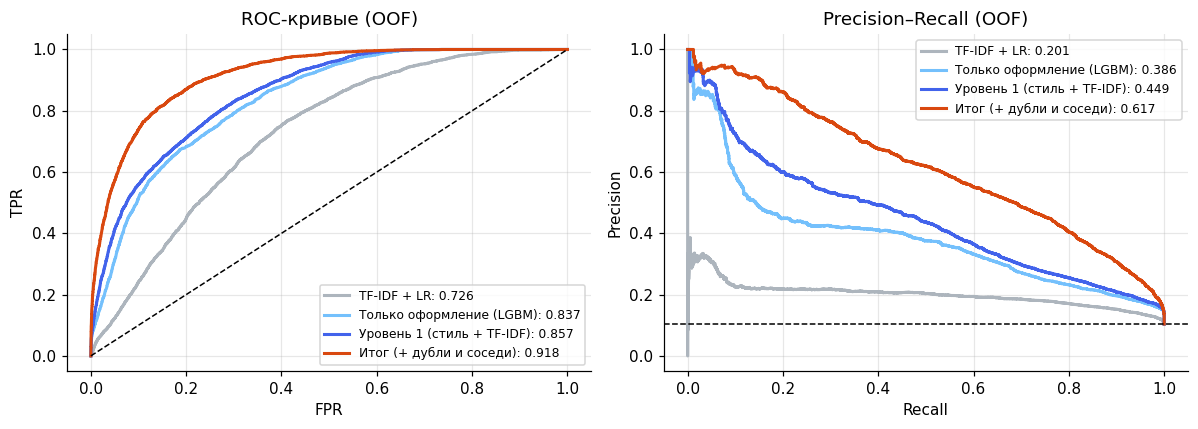

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
cols = ['#adb5bd', '#74c0fc', '#4263eb', EDITOR]
for (k, v), c in zip(oof.items(), cols):
    fpr, tpr, _ = roc_curve(y, v); axs[0].plot(fpr, tpr, color=c, lw=2, label=f'{k}: {roc_auc_score(y, v):.3f}')
    pr, rc, _ = precision_recall_curve(y, v); axs[1].plot(rc, pr, color=c, lw=2, label=f'{k}: {average_precision_score(y, v):.3f}')
axs[0].plot([0, 1], [0, 1], 'k--', lw=1); axs[0].set(title='ROC-кривые (OOF)', xlabel='FPR', ylabel='TPR')
axs[1].axhline(y.mean(), color='k', ls='--', lw=1); axs[1].set(title='Precision–Recall (OOF)', xlabel='Recall', ylabel='Precision')
for ax in axs: ax.legend(fontsize=8, loc='lower right' if ax is axs[0] else 'upper right')
plt.tight_layout(); plt.show()

Каждый слой добавляет качество. Одни слова дают скромные 0,73. Оформление поднимает AUC до 0,84, связка стиля и TF-IDF — до 0,86. Дубли и соседи дают ещё +0,06, это самый большой прирост.

## 6. Что пробовал и что не сработало

Чтобы ноутбук не считался час, перебор вынесен за его пределы. Итоги на тех же внешних фолдах:

| Эксперимент | ROC-AUC | Вывод |
|---|---|---|
| Второй уровень с исходными параметрами (lr 0,03, 31 лист, 700 деревьев) | 0,912 | отправная точка |
| lr 0,02, 15 листьев, 1 200 деревьев | 0,916 | мелкие деревья лучше |
| 63 листа | 0,908 | переобучение |
| **lr 0,01, 7 листьев, feature_fraction 0,5, 4 000 деревьев** | **0,918** | взял в работу |
| + морфология pymorphy3: доля слов не из словаря как прокси опечаток | 0,910 | сигнал слабый (AUC признака 0,52), не помог |
| + TF-IDF по леммам | 0,910 | дублирует словесный TF-IDF |
| + разница оформления вопроса и его двойников | 0,910 | модель уже ловит это через скор уровня 1 |

Честная оговорка: параметры второго уровня подбирались на тех же фолдах, по которым считается оценка. Поэтому 0,918 может быть завышено на пару тысячных. Надёжная оценка — «около 0,91–0,92».

Не проверял: эмбеддинги русскоязычных трансформеров (rubert-tiny2, sbert). В рабочем окружении нет доступа к HuggingFace. Это первое, что стоит попробовать дальше: скорее всего, они усилят текстовую часть уровня 1.

## 7. Порог для жёсткой метки

Если заказчику нужно не число, а решение «редактор / пользователь», порог подбираю на OOF-прогнозе по максимуму F1. При другой цене ошибки порог будет другим: например, если важнее не пропустить редакторский вопрос, его стоит сдвинуть вниз.

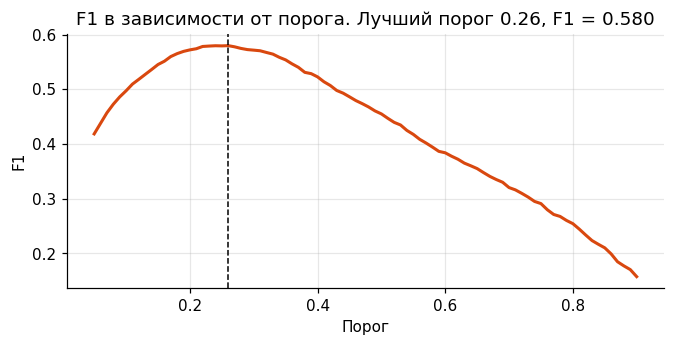

                    прогноз: пользователь  прогноз: редактор
факт: пользователь                  25168               1716
факт: редактор                       1144               1972

Precision 0.53: из вопросов, которые модель назвала редакторскими, столько действительно редакторские.
Recall    0.63: такую долю всех редакторских вопросов модель находит.


In [16]:
p = oof['Итог (+ дубли и соседи)']
ths = np.linspace(.05, .9, 86); f1s = [f1_score(y, p >= t) for t in ths]
t_best = ths[int(np.argmax(f1s))]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ths, f1s, color=EDITOR, lw=2); ax.axvline(t_best, color='k', ls='--', lw=1)
ax.set(title=f'F1 в зависимости от порога. Лучший порог {t_best:.2f}, F1 = {max(f1s):.3f}', xlabel='Порог', ylabel='F1'); plt.show()
cm = confusion_matrix(y, p >= t_best)
print(pd.DataFrame(cm, index=['факт: пользователь', 'факт: редактор'], columns=['прогноз: пользователь', 'прогноз: редактор']))
tn, fp, fn, tp = cm.ravel()
print(f'\nPrecision {tp/(tp+fp):.2f}: из вопросов, которые модель назвала редакторскими, столько действительно редакторские.')
print(f'Recall    {tp/(tp+fn):.2f}: такую долю всех редакторских вопросов модель находит.')

## 8. Где модель ошибается

In [17]:
err = tr[['ID', 'Question', 'Answer']].copy(); err['p'] = p
print('Модель уверена, что это РЕДАКТОР, но автор — пользователь:')
print(err[err.Answer == 0].nlargest(10, 'p')[['Question', 'p']].round(3).to_string(index=False))
print('\nМодель уверена, что это ПОЛЬЗОВАТЕЛЬ, но автор — редактор:')
print(err[err.Answer == 1].nsmallest(10, 'p')[['Question', 'p']].round(3).to_string(index=False))

Модель уверена, что это РЕДАКТОР, но автор — пользователь:
                                                                      Question     p
                          В какой стране впервые появилось слово «Библиотека»? 0.977
                              Что из этого НЕ является баскетбольным термином? 0.976
                В каком году советские войска одержали победу в Курской битве? 0.973
         Кто был воспитателем и наставником будущего императора Александра II? 0.973
      На какой максимальной высоте находился корабль во время полета Гагарина? 0.965
                            Какое из этих животных НЕ относится к роду пантер? 0.964
                     В каком году Финляндия вошла в состав Российской империи? 0.964
                               В каком году произошёл распад Советского Союза? 0.963
Чему посвящена серия марок СССР 1990 года со словами: спаси.пощади.остановись? 0.957
                                       Какой город является столицей Германии? 0.949

Модел

Я разобрал ошибки, у которых модель была увереннее всего. Их три типа.

* **Ложные «редакторы».** Аккуратные пользовательские вопросы вроде «Какой город является столицей Германии?». У каждого есть точный двойник, и он тоже помечен как пользовательский. По тексту и оформлению такой вопрос неотличим от редакторского. Похоже, игрок скопировал вопрос из игры, а сам редакторский оригинал в выгрузку не попал. Таких пар «пользователь + пользователь» в данных 428.
* **Редакторский оригинал среди десятков копий.** Вопрос «Сколько раз старик из сказки А. С. Пушкина вызывал Золотую рыбку?» встречается больше 40 раз слово в слово, и только один экземпляр редакторский. Текст одинаковый, поэтому угадать, какой из них оригинал, невозможно. Помогла бы дата создания вопроса, но её в данных нет.
* **Короткие редакторские вопросы без двойников** («Сколько ног у паука?», «Какой спирт смертельно ядовит?»). Опереться модели не на что, кроме стиля, а он у них как у рядового пользователя. Изредка встречаются и опечатки самих редакторов: «олимпииской», «Отцы и дети?».

В первых двух случаях нужны данные, которых в выгрузке нет. Моделью это не исправить.

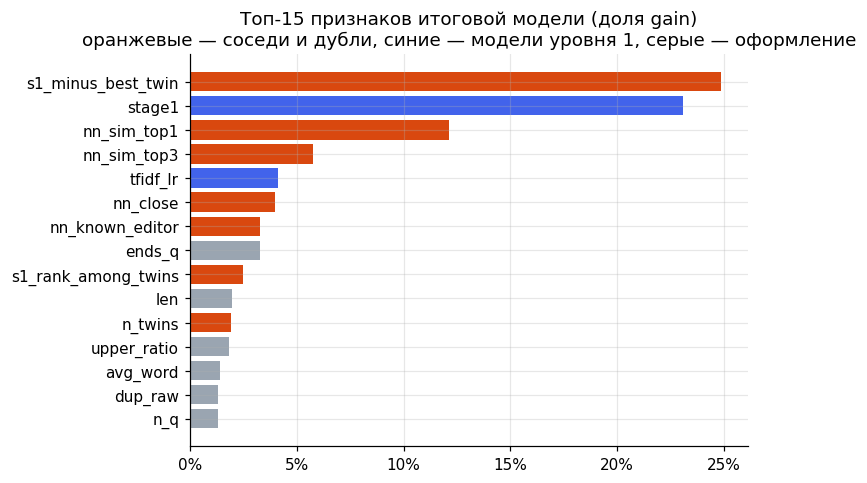

In [18]:
F_all, s_lr_all, s1_all = build_level2(itr, y, ite)
pred = np.zeros(len(ite)); imp = np.zeros(F_all.shape[1])
for sd in SEEDS:
    m = lgb.train(dict(P2, seed=sd), lgb.Dataset(F_all[itr], y), ROUNDS2)
    pred += m.predict(F_all[ite]) / len(SEEDS); imp += m.feature_importance('gain')
imp = pd.Series(imp / imp.sum(), FEAT_NAMES).sort_values()
top = imp.tail(15)
fig, ax = plt.subplots(figsize=(7, 4.5))
grp_color = lambda n: EDITOR if n in GROUP_NAMES else ('#4263eb' if n in ('tfidf_lr', 'stage1') else USER)
ax.barh(top.index, top.values, color=[grp_color(n) for n in top.index])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set(title='Топ-15 признаков итоговой модели (доля gain)\nоранжевые — соседи и дубли, синие — модели уровня 1, серые — оформление')
plt.tight_layout(); plt.show()

Главный признак — насколько вопрос «редакторее» своих двойников. Модель по сути решает, кто в паре оригинал. Дальше идёт скор первого уровня (стиль плюс текст) и сходство с ближайшими вопросами. Из чистого оформления сильнее всего работают знак вопроса в конце, длина и доля заглавных букв.

## 10. Файл с ответом

In [19]:
sub = pd.DataFrame({'ID': te.ID.values, 'Answer': pred})
sub.to_csv('submission.csv', index=False, header=False)   # формат как в baseline_solution.csv
base = pd.read_csv('baseline_solution.csv', header=None)
chk = pd.read_csv('submission.csv', header=None)
assert len(chk) == len(test_ids) and (chk[0].values == test_ids.ID.values).all() and chk[1].between(0, 1).all()
print(f'submission.csv: {len(chk)} строк, ID совпадают с test.csv, вероятности в [0, 1]')
print(f'Средняя вероятность {pred.mean():.3f} (доля редакторов в train {y.mean():.3f})')
print(f'Корреляция с baseline_solution.csv: {np.corrcoef(base[1], pred)[0,1]:.3f} — baseline, судя по всему, случайный')
print(f'Вопросов с вероятностью выше порога {t_best:.2f}: {(pred >= t_best).sum()} ({(pred >= t_best).mean():.1%})')
chk.head()

submission.csv: 11087 строк, ID совпадают с test.csv, вероятности в [0, 1]
Средняя вероятность 0.092 (доля редакторов в train 0.104)
Корреляция с baseline_solution.csv: 0.002 — baseline, судя по всему, случайный
Вопросов с вероятностью выше порога 0.26: 1255 (11.3%)


,0,1
0,30001,0.000509
1,30002,0.000203
2,30003,0.000452
3,30004,0.000253
4,30005,0.884256


## 11. Итоги

**Что получилось.** Модель отличает редакторские вопросы от пользовательских с ROC-AUC около **0,92** на честной вложенной кросс-валидации. Average Precision около 0,6 при доле класса 10%, то есть в шесть раз лучше случайного прогноза. Файл `submission.csv` готов в формате baseline.

**На чём держится модель:**
1. **Оформление.** Редактор не оставит вопрос без «?», не поставит прямые кавычки и не напишет капсом. Одни эти признаки дают AUC 0,84.
2. **Дубли.** Игроки присылают вопросы, которые видели в игре. В парах одинаковых вопросов почти всегда один редакторский, второй — копия. Модель учится определять, кто из них оригинал.

**Как применять.** Модель выдаёт вероятность. Для жёсткой метки порог из раздела 7 даёт максимальный F1. Если важнее не пропустить редакторский вопрос, порог стоит опустить.

**Что можно улучшить:**
* добавить эмбеддинги русскоязычного трансформера (rubert-tiny2 или sbert_large_nlu_ru) — нужен доступ к HuggingFace;
* уточнить у заказчика метрику и цену ошибок: от этого зависит порог;
* проверить разметку в группах дублей, где оба вопроса помечены одинаково;
* если в «Клевере» есть время появления вопроса, использовать его: оригинал в паре почти наверняка старше копии.